# H4 — LDI Across Bins (Repeated Measures ANOVA)

**Hypothesis:** LDI increases from Bin1 to Bin5 (items more similar to targets are better discriminated).

**Design:**
- Same participants contribute an LDI score at **each of 5 bins** → within-subjects (repeated measures)
- Participants are in one condition only → between-subjects
- We run a **one-way RM-ANOVA per condition** (within-factor: bin, 5 levels)

---
## Assumptions
1. **Normality** — LDI should be approximately normal at each bin level  
   → Shapiro-Wilk + Q-Q plots; if n > 25 CLT applies
2. **Sphericity** — variance of differences between all bin pairs must be equal  
   → Mauchly's test; if violated → Greenhouse-Geisser correction  
   → With 5 levels there are 10 difference pairs, so sphericity is harder to satisfy

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import shapiro, probplot, spearmanr
import pingouin as pg

sns.set(style='whitegrid', context='talk')

data_path = Path('..') / '01_Preprocessing' / 'compiled_preprocessed.csv'
df = pd.read_csv(data_path)

## Step 1 — Load Bin Mapping and Compute LDI per Bin

Bin assignments come from `01_Preprocessing/stimulus_bin_mapping.csv`  
(generated by `mst_preprocessing_bins.py` — condition-aware, handles `task_only` separately).

In [2]:
# load pre-built bin mapping (image_path × condition → bin)
bin_map = pd.read_csv(Path('..') / '01_Preprocessing' / 'stimulus_bin_mapping.csv')

# foil false-alarm rate per participant × condition
foil_rate = (
    df[df['trial_type'] == 'Foil']
    .groupby(['participant_id', 'condition'])['user_response']
    .apply(lambda s: (s == 'Lure').mean())
    .rename('foil_sim')
    .reset_index()
)

# lure hit rate per participant × condition × bin
lure_rate = (
    df[df['trial_type'] == 'Lure']
    .merge(bin_map[['image_path', 'condition', 'bin']], on=['image_path', 'condition'], how='left')
    .groupby(['participant_id', 'condition', 'bin'])['user_response']
    .apply(lambda s: (s == 'Lure').mean())
    .rename('lure_sim')
    .reset_index()
)

# LDI = lure hit rate − foil false-alarm rate
bin_df = lure_rate.merge(foil_rate, on=['participant_id', 'condition'], how='left')
bin_df['LDI'] = bin_df['lure_sim'] - bin_df['foil_sim']
bin_df['bin'] = bin_df['bin'].astype(int)

# sanity check: any images without a bin assignment?
missing = bin_df['bin'].isna().sum()
print(f'Missing bin assignments: {missing}')

# wide format: one row per participant, columns Bin1..Bin5
wide_df = (
    bin_df.pivot_table(index=['participant_id', 'condition'], columns='bin', values='LDI')
    .dropna()
    .reset_index()
)
wide_df.columns.name = None
wide_df = wide_df.rename(columns={1: 'Bin1', 2: 'Bin2', 3: 'Bin3', 4: 'Bin4', 5: 'Bin5'})
conditions = sorted(wide_df['condition'].unique())
bins = ['Bin1', 'Bin2', 'Bin3', 'Bin4', 'Bin5']

print(f'Complete participants: {len(wide_df)}')
print('\nParticipants per condition:')
display(wide_df.groupby('condition').size().rename('n'))
print('\nMean LDI per condition × bin:')
display(wide_df.groupby('condition')[bins].mean().round(4))

Missing bin assignments: 0
Complete participants: 160

Participants per condition:


condition
Both_item_task    51
item_only         56
task_only         53
Name: n, dtype: int64


Mean LDI per condition × bin:


,Bin1,Bin2,Bin3,Bin4,Bin5
condition,,,,,
Both_item_task,0.1745,0.2783,0.2486,0.3192,0.3199
item_only,0.1925,0.3421,0.3348,0.3688,0.3821
task_only,0.2485,0.3437,0.3964,0.4446,0.4713


In [5]:
def participant_ldi_table(condition: str) -> pd.DataFrame:
    """
    Returns a per-participant summary table for a given condition showing:
      - total_lures_shown    : number of Lure trials presented
      - total_lures_identified: how many they called 'Lure'
      - pct_identified       : total_lures_identified / total_lures_shown * 100
      - LDI per Bin (Bin1..Bin5)
      - foil_sim             : false-alarm rate on Foil trials

    Parameters
    ----------
    condition : str
        One of the values in df['condition']  (e.g. 'item_only', 'task_only', 'Both_item_task')
    """
    if condition not in df['condition'].unique():
        raise ValueError(f"Unknown condition '{condition}'. Available: {sorted(df['condition'].unique())}")

    cond_df = df[df['condition'] == condition]

    # ── counts: lures shown vs identified ────────────────────────────────────
    lure_trials = cond_df[cond_df['trial_type'] == 'Lure']
    counts = (
        lure_trials
        .groupby('participant_id')
        .agg(
            total_lures_shown=('user_response', 'count'),
            total_lures_identified=('user_response', lambda s: (s == 'Lure').sum())
        )
        .reset_index()
    )
    counts['pct_identified'] = (
        counts['total_lures_identified'] / counts['total_lures_shown'] * 100
    ).round(1)

    # ── foil false-alarm rate ─────────────────────────────────────────────────
    foil = (
        cond_df[cond_df['trial_type'] == 'Foil']
        .groupby('participant_id')['user_response']
        .apply(lambda s: (s == 'Lure').mean())
        .rename('foil_sim')
        .reset_index()
    )

    # ── LDI per bin (already computed in bin_df) ──────────────────────────────
    ldi_wide = (
        bin_df[bin_df['condition'] == condition][['participant_id', 'bin', 'LDI']]
        .pivot(index='participant_id', columns='bin', values='LDI')
        .rename(columns={1: 'Bin1', 2: 'Bin2', 3: 'Bin3', 4: 'Bin4', 5: 'Bin5'})
        .reset_index()
    )
    ldi_wide.columns.name = None

    # ── merge all columns ─────────────────────────────────────────────────────
    table = (
        counts
        .merge(foil, on='participant_id', how='left')
        .merge(ldi_wide, on='participant_id', how='left')
        .sort_values('participant_id')
        .reset_index(drop=True)
    )
    table['foil_sim'] = table['foil_sim'].round(4)
    for b in ['Bin1', 'Bin2', 'Bin3', 'Bin4', 'Bin5']:
        if b in table.columns:
            table[b] = table[b].round(4)

    return table


# ── Demo: show summary for each condition ────────────────────────────────────
for cond in conditions:
    print(f"\n{'='*60}")
    print(f"  Condition: {cond}")
    print(f"{'='*60}")
    t = participant_ldi_table(cond)
    # summary row at the bottom
    summary = t[['total_lures_shown', 'total_lures_identified', 'pct_identified',
                  'foil_sim', 'Bin1', 'Bin2', 'Bin3', 'Bin4', 'Bin5']].mean().round(4)
    summary.name = 'MEAN'
    display(pd.concat([t, summary.to_frame().T.reset_index(drop=True)], ignore_index=False))


  Condition: Both_item_task


,participant_id,total_lures_shown,total_lures_identified,pct_identified,foil_sim,Bin1,Bin2,Bin3,Bin4,Bin5
0,15.0,60.0,23.0000,38.3000,0.1667,0.3333,0.0833,-0.0238,0.3667,0.2500
1,16.0,60.0,39.0000,65.0000,0.1000,0.4833,0.3615,0.5000,0.8000,0.7000
2,17.0,60.0,33.0000,55.0000,0.1667,0.3000,0.5000,0.4167,0.4167,0.3333
3,18.0,60.0,29.0000,48.3000,0.6333,-0.2333,-0.0333,-0.2487,-0.2333,0.0333
4,19.0,60.0,21.0000,35.0000,0.2000,0.0857,0.0667,0.2000,0.1077,0.2667
5,20.0,60.0,36.0000,60.0000,0.3667,0.1627,0.0879,0.2697,0.3606,0.3333
6,21.0,60.0,20.0000,33.3000,0.1667,0.1333,0.0833,0.1905,0.1667,0.2500
7,22.0,60.0,19.0000,31.7000,0.3667,-0.2000,-0.0095,0.0451,-0.1000,-0.1167
8,23.0,60.0,36.0000,60.0000,0.2333,0.2667,0.5667,0.1303,0.4939,0.3917
9,24.0,60.0,23.0000,38.3000,0.2667,0.0190,0.4833,-0.0524,0.0905,0.2333



  Condition: item_only


,participant_id,total_lures_shown,total_lures_identified,pct_identified,foil_sim,Bin1,Bin2,Bin3,Bin4,Bin5
0,1.0,60.0,34.0000,56.7000,0.2667,0.2788,0.3697,0.2889,0.2333,0.3333
1,2.0,60.0,25.0000,41.7000,0.1667,0.2500,0.1970,0.3333,0.0833,0.3667
2,3.0,60.0,18.0000,30.0000,0.3667,-0.0810,-0.0810,-0.1848,0.1333,-0.0939
3,4.0,60.0,33.0000,55.0000,0.2000,-0.0125,0.3556,0.3385,0.6333,0.6000
4,5.0,60.0,36.0000,60.0000,0.3667,0.0333,0.4515,0.2583,0.3476,-0.0333
5,6.0,60.0,31.0000,51.7000,0.0667,0.3500,0.4889,0.5762,0.3500,0.4718
6,7.0,60.0,13.0000,21.7000,0.1333,0.0095,-0.0424,0.1524,0.2000,0.1167
7,8.0,60.0,32.0000,53.3000,0.0667,0.3500,0.3619,0.2667,0.5762,0.6667
8,9.0,60.0,33.0000,55.0000,0.3333,0.0000,0.2222,0.2500,0.4167,0.2500
9,10.0,60.0,25.0000,41.7000,0.3667,-0.0333,0.0619,0.1333,0.1333,-0.0810



  Condition: task_only


,participant_id,total_lures_shown,total_lures_identified,pct_identified,foil_sim,Bin1,Bin2,Bin3,Bin4,Bin5
0,19.0,60.0,25.0000,41.7000,0.3333,-0.0333,-0.1515,0.0417,0.1667,0.4444
1,20.0,60.0,25.0000,41.7000,0.2000,0.0857,0.2667,0.1333,0.5000,0.1333
2,21.0,60.0,38.0000,63.3000,0.2000,0.4000,0.3714,0.4667,0.4364,0.4667
3,22.0,60.0,42.0000,70.0000,0.1667,0.1970,0.3333,0.5333,0.7222,0.7333
4,23.0,60.0,35.0000,58.3000,0.4000,0.0286,0.0545,0.2000,0.1625,0.4571
5,24.0,60.0,52.0000,86.7000,0.1333,0.6167,0.7000,0.8042,0.6444,0.8000
6,25.0,60.0,36.0000,60.0000,0.2333,0.2042,0.3500,0.6758,0.1000,0.5167
7,26.0,60.0,35.0000,58.3000,0.3000,-0.0273,-0.1750,0.3364,0.4143,0.5750
8,27.0,60.0,42.0000,70.0000,0.0667,0.4333,0.2667,0.7190,0.7905,0.8424
9,28.0,60.0,45.0000,75.0000,0.0667,0.6980,0.6333,0.6333,0.8083,0.6667


---
## Assumption 1 — Normality (Shapiro-Wilk + Q-Q plots)

Check normality of LDI at each bin within each condition.

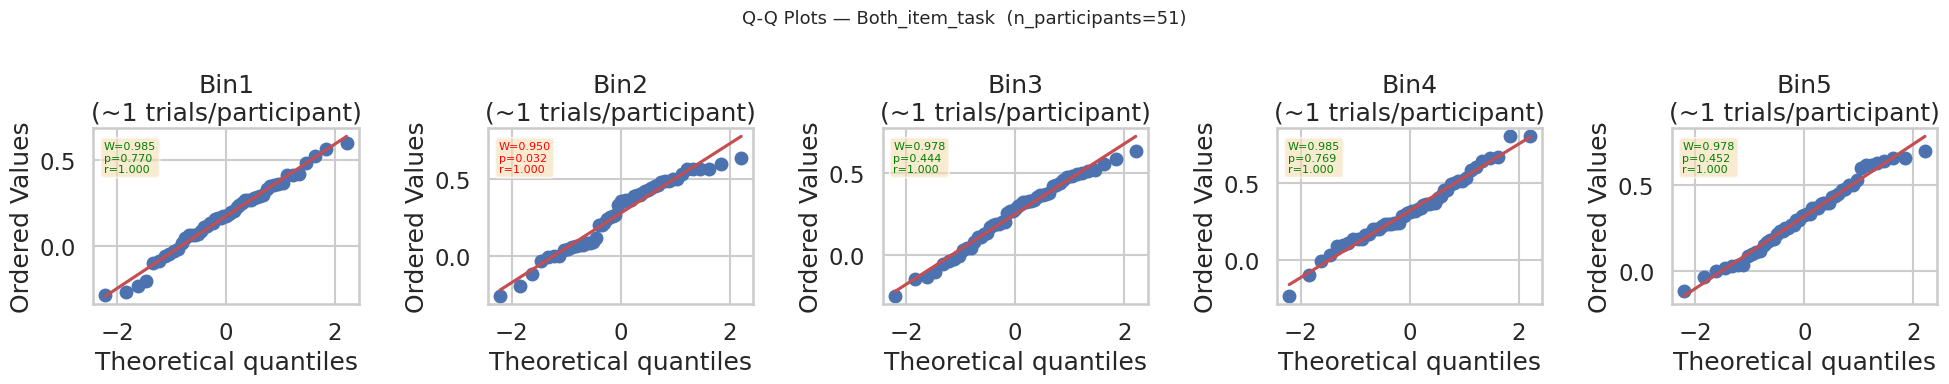

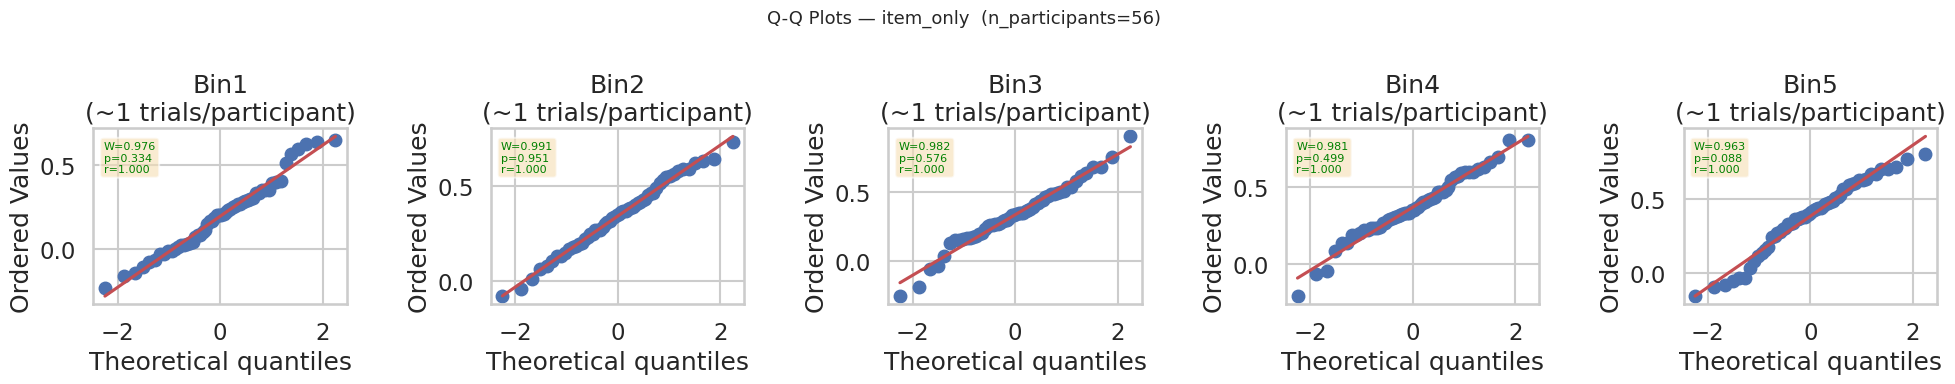

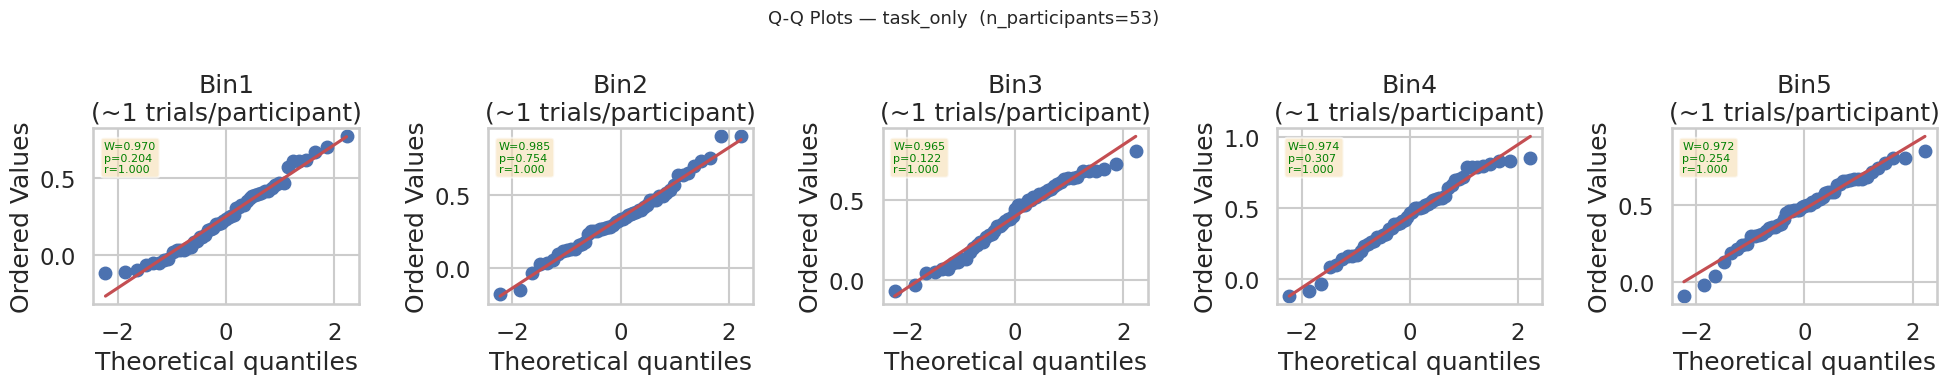


Normality Summary:


,condition,bin,n_participants,avg_trials_per_pp,shapiro_W,shapiro_p,normal (p>.05),n>25 (CLT),QQ_spearman_r
0,Both_item_task,Bin1,51,1.0,0.9852,0.7702,True,True,1.0000
1,Both_item_task,Bin2,51,1.0,0.9501,0.0317,False,True,0.9998
2,Both_item_task,Bin3,51,1.0,0.9777,0.4445,True,True,1.0000
3,Both_item_task,Bin4,51,1.0,0.9852,0.7690,True,True,0.9999
4,Both_item_task,Bin5,51,1.0,0.9779,0.4522,True,True,0.9997
5,item_only,Bin1,56,1.0,0.9763,0.3341,True,True,0.9999
6,item_only,Bin2,56,1.0,0.9910,0.9509,True,True,0.9999
7,item_only,Bin3,56,1.0,0.9822,0.5760,True,True,0.9999
8,item_only,Bin4,56,1.0,0.9805,0.4994,True,True,0.9998
9,item_only,Bin5,56,1.0,0.9635,0.0879,True,True,0.9999


In [6]:
normality_results = []

# trials per participant per bin (to report alongside normality)
trials_per_pp = (
    bin_df.groupby(['condition', 'participant_id', 'bin'])
    .size()
    .reset_index(name='n_trials')
    .groupby(['condition', 'bin'])['n_trials']
    .mean()
    .round(1)
)

for cond in conditions:
    cond_data = wide_df[wide_df['condition'] == cond]
    n_participants = len(cond_data)

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f'Q-Q Plots — {cond}  (n_participants={n_participants})', fontsize=13)

    for ax, b in zip(axes, bins):
        vals = cond_data[b].dropna()
        bin_num = int(b.replace('Bin', ''))
        avg_trials = trials_per_pp.get((cond, bin_num), float('nan'))

        (osm, osr), _ = probplot(vals, dist='norm', plot=ax)
        ax.set_title(f'{b}\n(~{avg_trials:.0f} trials/participant)')

        sw_stat, sw_p  = shapiro(vals)
        spear_r, _     = spearmanr(osm, osr)

        normality_results.append({
            'condition':        cond,
            'bin':              b,
            'n_participants':   n_participants,
            'avg_trials_per_pp': avg_trials,
            'shapiro_W':        round(sw_stat, 4),
            'shapiro_p':        round(sw_p, 4),
            'normal (p>.05)':   sw_p > 0.05,
            'n>25 (CLT)':       n_participants > 25,
            'QQ_spearman_r':    round(spear_r, 4),
        })

        color = 'green' if sw_p > 0.05 else 'red'
        ax.annotate(
            f'W={sw_stat:.3f}\np={sw_p:.3f}\nr={spear_r:.3f}',
            xy=(0.04, 0.75), xycoords='axes fraction', fontsize=8,
            color=color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.6)
        )

    plt.tight_layout()
    plt.show()

norm_df = pd.DataFrame(normality_results)
print('\nNormality Summary:')
display(norm_df)

---
## Assumption 2 — Sphericity (Mauchly's Test)

With 5 bins there are **10 pairwise difference variances** that must be equal.  
Sphericity is harder to satisfy with more levels — GG correction is commonly needed.

- **p > .05** → sphericity holds → standard F-statistic valid  
- **p < .05** → violated → use Greenhouse-Geisser corrected F  
- **GG ε < 0.75** → strong violation | **ε > 0.75** → mild violation

In [7]:
sphericity_results = []

for cond in conditions:
    cols = wide_df[wide_df['condition'] == cond][bins]

    spher, W, chi2, dof, p_val = pg.sphericity(cols)
    gg = pg.epsilon(cols, correction='gg')

    sphericity_results.append({
        'condition': cond,
        'Mauchly_W': round(W, 4),
        'chi2': round(chi2, 4),
        'df': dof,
        'p_value': round(p_val, 4),
        'sphericity_holds (p>.05)': p_val > 0.05,
        'GG_epsilon': round(gg, 4),
        'GG_needed': p_val < 0.05,
    })

sph_df = pd.DataFrame(sphericity_results)
print("Mauchly's Sphericity Test:")
display(sph_df)

Mauchly's Sphericity Test:


,condition,Mauchly_W,chi2,df,p_value,sphericity_holds (p>.05),GG_epsilon,GG_needed
0,Both_item_task,0.7843,11.7657,9,0.2271,True,0.8942,False
1,item_only,0.8860,6.4627,9,0.6930,True,0.9483,False
2,task_only,0.7718,13.0615,9,0.1601,True,0.8806,False


---
## Assumption Summary & Decision

In [8]:
summary_rows = []
for cond in conditions:
    cn = norm_df[norm_df['condition'] == cond]
    all_normal = cn['normal (p>.05)'].all()
    all_clt    = cn['n>25 (CLT)'].all()
    norm_ok    = all_normal or all_clt
    norm_note  = ('Yes — Shapiro p>.05' if all_normal
                  else 'Yes — n>25, CLT' if all_clt
                  else 'NO — violated')

    sr      = sph_df[sph_df['condition'] == cond].iloc[0]
    sph_ok  = sr['sphericity_holds (p>.05)']
    sph_note = (f"Yes — Mauchly p={sr['p_value']}" if sph_ok
                else f"NO — violated (ε={sr['GG_epsilon']})")

    if not norm_ok:
        test = 'Friedman test (non-parametric)'
    elif sph_ok:
        test = 'RM-ANOVA (standard)'
    else:
        test = 'RM-ANOVA + Greenhouse-Geisser correction'

    summary_rows.append({'Condition': cond, 'Normality': norm_note,
                         'Sphericity': sph_note, 'Recommended Test': test})

display(pd.DataFrame(summary_rows))

,Condition,Normality,Sphericity,Recommended Test
0,Both_item_task,"Yes — n>25, CLT",Yes — Mauchly p=0.2271,RM-ANOVA (standard)
1,item_only,Yes — Shapiro p>.05,Yes — Mauchly p=0.693,RM-ANOVA (standard)
2,task_only,Yes — Shapiro p>.05,Yes — Mauchly p=0.1601,RM-ANOVA (standard)


---
## Step 3 — One-Way RM-ANOVA per Condition (within: bin)

- **F significant (p<.05)** → LDI differs across at least one pair of bins
- **η²g** — generalized eta-squared (effect size)  
  < 0.06 small | 0.06–0.14 medium | > 0.14 large
- **eps** — GG epsilon reported by pingouin; if < 1 and sphericity was violated, GG-corrected p should be used

In [9]:
# long format needed by pingouin
long_df = wide_df.melt(
    id_vars=['participant_id', 'condition'],
    value_vars=bins,
    var_name='bin', value_name='LDI'
)
long_df['bin'] = pd.Categorical(long_df['bin'], categories=bins, ordered=True)

anova_results = []
for cond in conditions:
    cond_long = long_df[long_df['condition'] == cond]

    aov  = pg.rm_anova(data=cond_long, dv='LDI', within='bin',
                       subject='participant_id')
    row  = aov.iloc[0]
    eta2 = row['ng2']
    p    = row['p_unc']

    # GG-corrected p if sphericity was violated
    sr     = sph_df[sph_df['condition'] == cond].iloc[0]
    p_gg   = row.get('p_GG-corr', np.nan) if sr['GG_needed'] else p

    anova_results.append({
        'condition': cond,
        'F': round(row['F'], 4),
        'df_num': int(row['ddof1']),
        'df_den': int(row['ddof2']),
        'p_unc': round(p, 4),
        'GG_epsilon': round(sr['GG_epsilon'], 4),
        'p_GG_corrected': round(p_gg, 4) if not np.isnan(p_gg) else '—',
        'significant (p<.05)': p < 0.05,
        'η²g': round(eta2, 4),
        'effect size': ('large' if eta2 > 0.14 else 'medium' if eta2 > 0.06 else 'small')
    })

anova_df = pd.DataFrame(anova_results)
print('One-Way RM-ANOVA — LDI ~ bin (per condition)')
display(anova_df)

One-Way RM-ANOVA — LDI ~ bin (per condition)


,condition,F,df_num,df_den,p_unc,GG_epsilon,p_GG_corrected,significant (p<.05),η²g,effect size
0,Both_item_task,10.0979,4,200,0.0,0.8942,0.0,True,0.0616,medium
1,item_only,17.3487,4,220,0.0,0.9483,0.0,True,0.0962,medium
2,task_only,20.6390,4,208,0.0,0.8806,0.0,True,0.1091,medium


---
## Step 4 — Post-Hoc Pairwise Tests (Bonferroni)

Run only for conditions where ANOVA is significant.  
With 5 bins there are 10 pairwise comparisons — Bonferroni correction is applied.

In [10]:
posthoc_all = []

for cond in conditions:
    aov_row = anova_df[anova_df['condition'] == cond].iloc[0]
    if not aov_row['significant (p<.05)']:
        print(f"{cond}: ANOVA not significant (p={aov_row['p_unc']}) — skipping post-hoc.\n")
        continue

    print(f'{cond}: ANOVA significant — running post-hoc.')
    cond_long = long_df[long_df['condition'] == cond]

    ph = pg.pairwise_tests(
        data=cond_long, dv='LDI', within='bin',
        subject='participant_id', padjust='bonf', parametric=True
    )
    ph = ph[['A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'p_adjust', 'hedges']].copy()
    ph.insert(0, 'condition', cond)
    ph = ph.rename(columns={'T': 't_stat', 'p_unc': 'p_raw',
                             'p_corr': 'p_bonferroni', 'hedges': "Hedges' g"})
    ph['significant (bonf)'] = ph['p_bonferroni'] < 0.05
    posthoc_all.append(ph)

if posthoc_all:
    posthoc_df = pd.concat(posthoc_all, ignore_index=True)
    print('\nPost-Hoc Results (Bonferroni corrected):')
    display(posthoc_df)
else:
    print('No significant ANOVA — no post-hoc tests run.')

Both_item_task: ANOVA significant — running post-hoc.
item_only: ANOVA significant — running post-hoc.
task_only: ANOVA significant — running post-hoc.

Post-Hoc Results (Bonferroni corrected):


,condition,A,B,t_stat,dof,p_raw,p_bonferroni,p_adjust,Hedges' g,significant (bonf)
0,Both_item_task,Bin1,Bin2,-3.241236,50.0,2.120383e-03,2.120383e-02,bonf,-0.474847,True
1,Both_item_task,Bin1,Bin3,-2.783371,50.0,7.573060e-03,7.573060e-02,bonf,-0.354502,False
2,Both_item_task,Bin1,Bin4,-5.649935,50.0,7.620046e-07,7.620046e-06,bonf,-0.686349,True
3,Both_item_task,Bin1,Bin5,-5.222272,50.0,3.434959e-06,3.434959e-05,bonf,-0.698926,True
4,Both_item_task,Bin2,Bin3,1.037735,50.0,3.043860e-01,1.000000e+00,bonf,0.134785,False
5,Both_item_task,Bin2,Bin4,-1.363510,50.0,1.788299e-01,1.000000e+00,bonf,-0.184251,False
6,Both_item_task,Bin2,Bin5,-1.594492,50.0,1.171282e-01,1.000000e+00,bonf,-0.189620,False
7,Both_item_task,Bin3,Bin4,-2.813798,50.0,6.982105e-03,6.982105e-02,bonf,-0.332093,False
8,Both_item_task,Bin3,Bin5,-3.353836,50.0,1.526495e-03,1.526495e-02,bonf,-0.339781,True
9,Both_item_task,Bin4,Bin5,-0.028990,50.0,9.769883e-01,1.000000e+00,bonf,-0.003236,False


---
## Step 5 — Visualizations

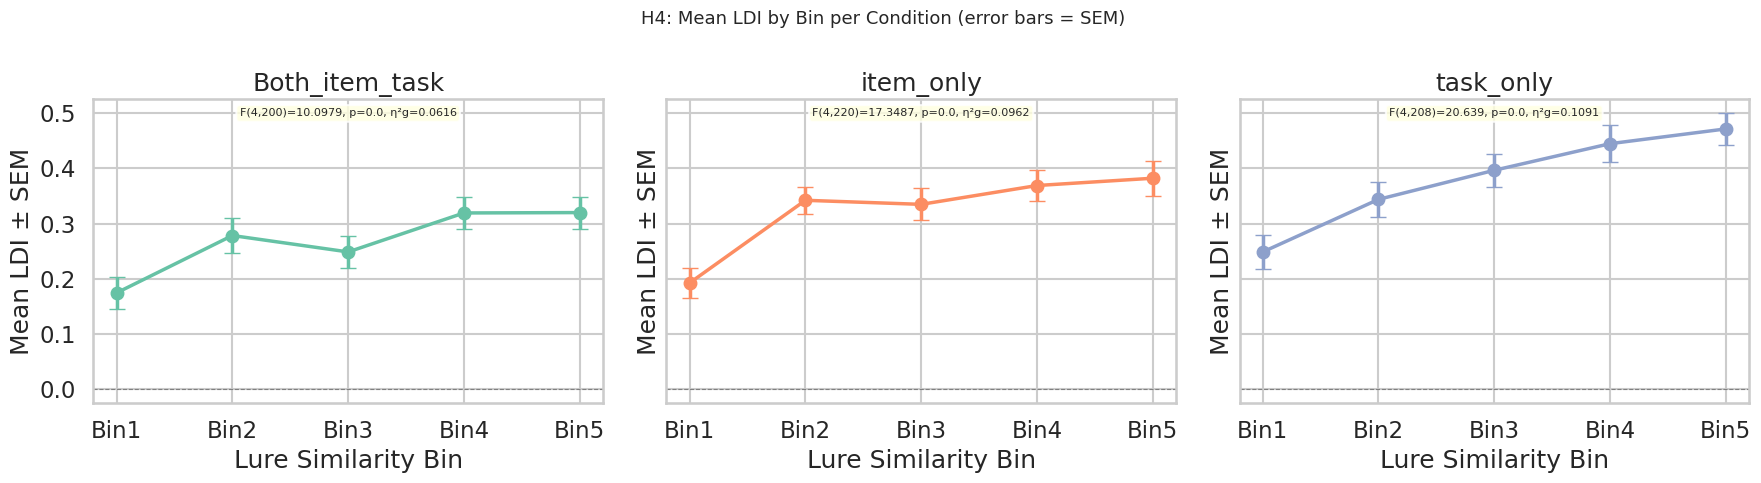

/tmp/ipykernel_571445/24192846.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cond_long, x='bin', y='LDI', order=bins,
/tmp/ipykernel_571445/24192846.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cond_long, x='bin', y='LDI', order=bins,
/tmp/ipykernel_571445/24192846.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cond_long, x='bin', y='LDI', order=bins,


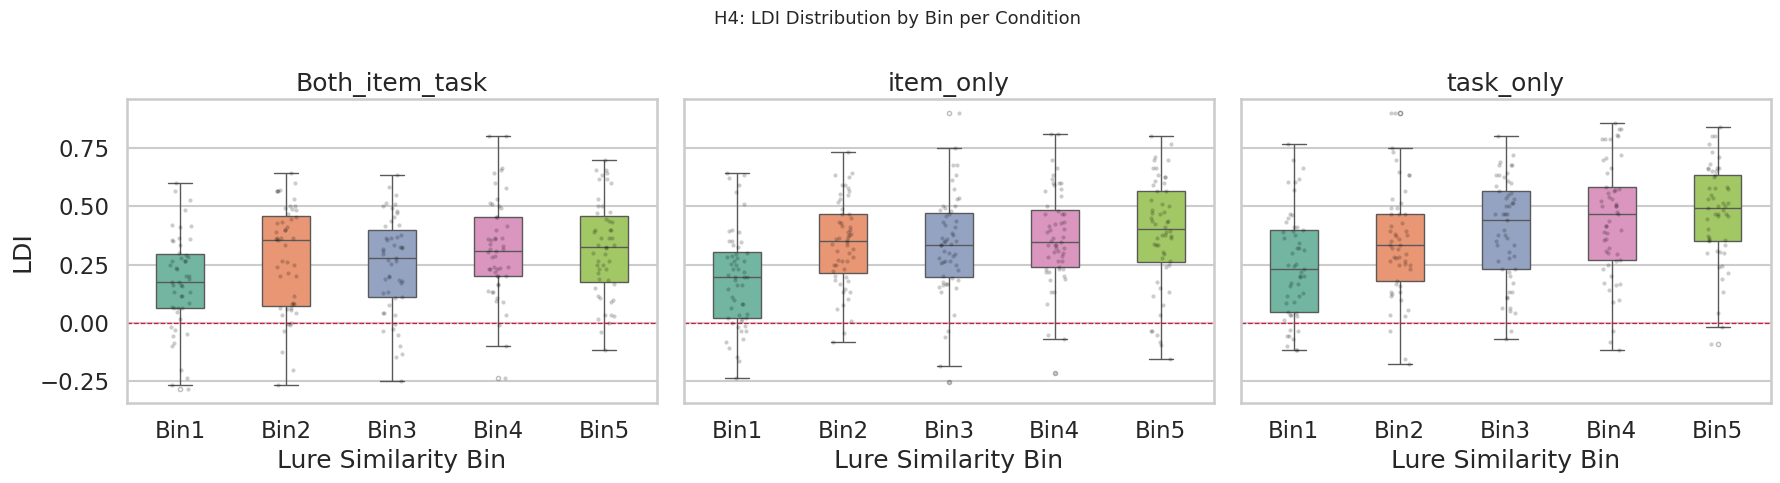

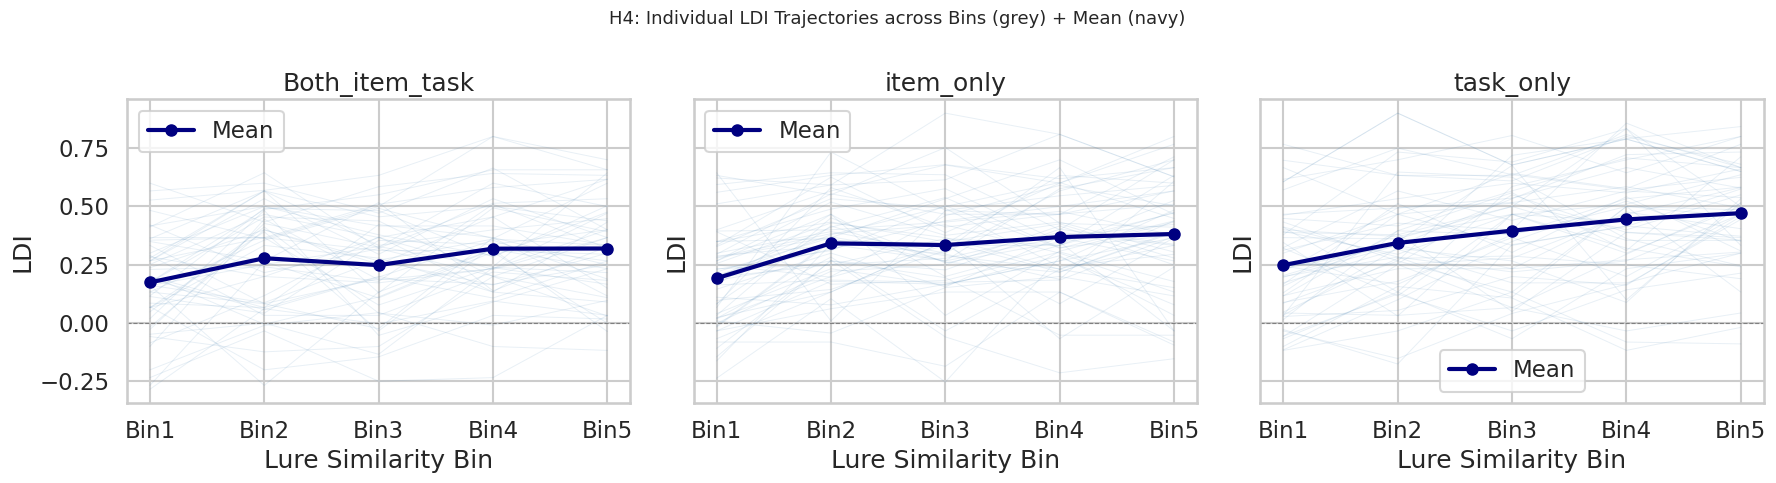

In [11]:
def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

palette = sns.color_palette('Set2', len(conditions))

# ── Plot 1: Mean LDI per bin per condition (line + SEM) ───────────────────────
fig, axes = plt.subplots(1, len(conditions), figsize=(6*len(conditions), 5), sharey=True)
if len(conditions) == 1: axes = [axes]

for ax, cond, color in zip(axes, conditions, palette):
    cond_long = long_df[long_df['condition'] == cond]
    means = cond_long.groupby('bin', observed=True)['LDI'].agg(['mean','sem']).reindex(bins)
    ax.errorbar(bins, means['mean'], yerr=means['sem'],
                marker='o', linewidth=2.5, markersize=9, capsize=6, color=color)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(cond)
    ax.set_xlabel('Lure Similarity Bin')
    ax.set_ylabel('Mean LDI ± SEM')
    ar = anova_df[anova_df['condition'] == cond].iloc[0]
    ax.annotate(f"F({ar['df_num']},{ar['df_den']})={ar['F']}, p={ar['p_unc']}, η²g={ar['η²g']}",
                xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.suptitle('H4: Mean LDI by Bin per Condition (error bars = SEM)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Plot 2: Box + strip ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(conditions), figsize=(6*len(conditions), 5), sharey=True)
if len(conditions) == 1: axes = [axes]

for ax, cond in zip(axes, conditions):
    cond_long = long_df[long_df['condition'] == cond]
    sns.boxplot(data=cond_long, x='bin', y='LDI', order=bins,
                palette='Set2', width=0.45, ax=ax,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
    sns.stripplot(data=cond_long, x='bin', y='LDI', order=bins,
                  color='black', alpha=0.2, size=3, jitter=True, ax=ax)
    ax.axhline(0, color='crimson', linestyle='--', linewidth=0.9)
    ax.set_title(cond)
    ax.set_xlabel('Lure Similarity Bin')
    ax.set_ylabel('LDI')

plt.suptitle('H4: LDI Distribution by Bin per Condition', fontsize=13)
plt.tight_layout()
plt.show()

# ── Plot 3: Spaghetti (individual trajectories) ───────────────────────────────
fig, axes = plt.subplots(1, len(conditions), figsize=(6*len(conditions), 5), sharey=True)
if len(conditions) == 1: axes = [axes]

for ax, cond in zip(axes, conditions):
    cond_wide = wide_df[wide_df['condition'] == cond]
    for _, row in cond_wide.iterrows():
        ax.plot(bins, [row[b] for b in bins],
                color='steelblue', alpha=0.12, linewidth=0.7)
    means = [cond_wide[b].mean() for b in bins]
    ax.plot(bins, means, color='navy', linewidth=3, marker='o', markersize=8, label='Mean')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(cond)
    ax.set_xlabel('Lure Similarity Bin')
    ax.set_ylabel('LDI')
    ax.legend()

plt.suptitle('H4: Individual LDI Trajectories across Bins (grey) + Mean (navy)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Conclusions — H4: LDI Increases from Bin1 to Bin5

### RM-ANOVA Summary
All three conditions showed a **highly significant effect of bin on LDI** (p < .001), with medium effect sizes (η²g = 0.06–0.11). Lure-similarity bin meaningfully changes how well participants discriminate lures from targets.

| Condition | F | df | η²g | Effect Size |
|---|---|---|---|---|
| Both_item_task | F(4, 200) = 10.10 | — | 0.062 | Medium |
| item_only | F(4, 220) = 17.35 | — | 0.096 | Medium |
| task_only | F(4, 208) = 20.64 | — | 0.109 | Medium |

Sphericity held for all conditions (Mauchly p > .05), so standard RM-ANOVA F-statistics are valid.

---

### Post-Hoc Bonferroni — Which Bins Actually Differ?

#### Both_item_task
- **Bin1 < Bin2, Bin4, Bin5** (p < .05) — Bin1 is consistently the lowest
- Bin3 < Bin5 (p = .015)
- Bins 2–5 largely plateau (no significant differences among each other)
- Pattern: **step up from Bin1, then plateau**

#### item_only
- **Bin1 significantly lower than ALL other bins** (Bin2–5, all p < .001)
- Bins 2–5 do not differ from each other at all
- Hedges' g up to |0.85| — large effect for Bin1 vs Bin4/5
- Pattern: **sharp step from Bin1 to Bin2, then flat**

#### task_only
- **Bin1 < all other bins** (p < .001)
- **Bin2 < Bin4** (p = .012) and **Bin2 < Bin5** (p = .004) — gradient continues beyond Bin1
- **Bin3 < Bin5** (p = .035)
- Hedges' g for Bin1 vs Bin5 = **|1.01|** — large effect (rare in behavioral data)
- Pattern: **closest to a true monotonic gradient** across all 5 bins

---

### Overall Interpretation

**H4 is supported** — LDI increases from Bin1 (most target-similar lures) toward higher bins (less similar lures), consistent with the prediction that the brain performs better pattern separation for perceptually less confusable items.

However, the increase is **not perfectly monotonic** in all conditions:
- **item_only** and **Both_item_task**: step-function shape — Bin1 is the clear outlier; Bins 2–5 plateau
- **task_only**: closest to a true gradient, with significant differences persisting even among Bins 2–5

**What this means mechanistically:** The hardest discrimination task (Bin1 — very similar to target) is the most impaired. Once a lure is sufficiently dissimilar from the target, further dissimilarity yields diminishing returns in LDI. The `task_only` condition's richer gradient suggests stronger encoding that allows the memory system to differentiate even moderately dissimilar lures.

---

### Effect Size Reference (η²g)
| η²g | Interpretation |
|---|---|
| < 0.06 | Small |
| 0.06 – 0.14 | Medium |
| > 0.14 | Large |

### Post-Hoc Effect Size Reference (Hedges' g)
| \|g\| | Interpretation |
|---|---|
| < 0.20 | Negligible |
| 0.20 – 0.50 | Small |
| 0.50 – 0.80 | Medium |
| > 0.80 | Large |